<a href="https://colab.research.google.com/github/joaov-fin/quantitative-finance-lab/blob/main/Adaptive_Volatility_Trader_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### *Adaptive Volatility Trader Strategy*
This strategy builds a regression-based trading model that adapts to market volatility regimes using the Bovespa Index (IBOVESPA) as a reference.

It starts by analyzing the relationship between daily volatility (measured as the rolling standard deviation of next-day price moves) and the direction of the following day’s intraday return.
A simple linear regression without intercept estimates a coefficient (β) linking the volatility level to the probability of a positive next-day move.

The regression output is then binned into ranges, and the model identifies the threshold (limit_trade) where the first few bins yield predominantly positive returns.
This threshold defines the trading regime:

- Go long (buy) when the regression value ≤ threshold (low-volatility environment)

- Go short (sell) when the regression value > threshold (high-volatility environment)

The model’s performance is evaluated on three time segments — Training (70%), Validation (15%), and Test (15%) — to ensure robustness and avoid overfitting.
Each segment reports cumulative return, Sharpe ratio, hit rate, and maximum drawdown, benchmarked against a Buy-and-Hold strategy.

In essence, the Adaptive Volatility Trader aims to exploit shifts in volatility as leading indicators of short-term market direction — adapting its position between bullish and bearish regimes based on statistical patterns in past price behavior.

In [105]:
# Libraries

!pip install yfinance -q

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression


In [106]:
# Load Historical data
ticker = '^BVSP'
data = yf.download(ticker, start='2016-01-01', auto_adjust = False)

# Shift next-day prices
data['close_next_day'] = data['Close'].shift(-1)
data['open_next_day'] = data['Open'].shift(-1)

# Next-day price move
data['diff_next_day'] = data['close_next_day'] - data['open_next_day']

# Trading signal
# 1 if next-day move is positive, 0 otherwise
data['signal'] = np.where(data['diff_next_day']>0, 1, 0)

# Rolling Volatility
# Standard deviation of next-day moves over the last period days
vol_period = 20
data['volatility'] = data['diff_next_day'].rolling(window=vol_period).std()

# Drop NA values
data = data.dropna()

[*********************100%***********************]  1 of 1 completed


In [107]:
# Split the dataset into train/validation/test
n = len(data)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train = data.iloc[:train_end].copy() # First 70%
val   = data.iloc[train_end:val_end].copy() # Next 15%
test  = data.iloc[val_end:].copy() # Last 15%

print(f"Train size: {len(train)} | Validation size: {len(val)} | Test size: {len(test)}")

Train size: 1689 | Validation size: 362 | Test size: 363


In [108]:
# Train regression model
# Simple regression: vol = beta * signal; No intercept
X_train = train[['signal']]
y_train = train['volatility']

model = LinearRegression(fit_intercept = False)
model.fit(X_train, y_train)

beta = model.coef_[0]

print("Coefficient (beta):", beta)

Coefficient (beta): 1221.590600011972


In [109]:
# Apply regression to each dataset
train['regression'] = beta * train['volatility']
val['regression']   = beta * val['volatility']
test['regression']  = beta * test['volatility']

In [110]:
# Create bins for regression column
# Split into 20 equal width intervals
bins = np.linspace(train['regression'].min(), train['regression'].max(), 20)
train['regression_bin'] = pd.cut(train['regression'], bins=bins)

# Group by bins and sum next-day differences
table_bins = (
    train.groupby('regression_bin',  observed=False)['diff_next_day']
    .sum()
    .reset_index()
    .rename(columns={'diff_next_day': 'sum_diff_next_day'})
)

In [111]:
table_bins

,regression_bin,sum_diff_next_day
0,"(503316.687, 893980.988]",28534.0
1,"(893980.988, 1284645.29]",34899.0
2,"(1284645.29, 1675309.591]",24129.0
3,"(1675309.591, 2065973.893]",3515.0
4,"(2065973.893, 2456638.195]",15757.0
5,"(2456638.195, 2847302.496]",-11641.0
6,"(2847302.496, 3237966.798]",-7780.0
7,"(3237966.798, 3628631.1]",1846.0
8,"(3628631.1, 4019295.401]",0.0
9,"(4019295.401, 4409959.703]",-11925.0


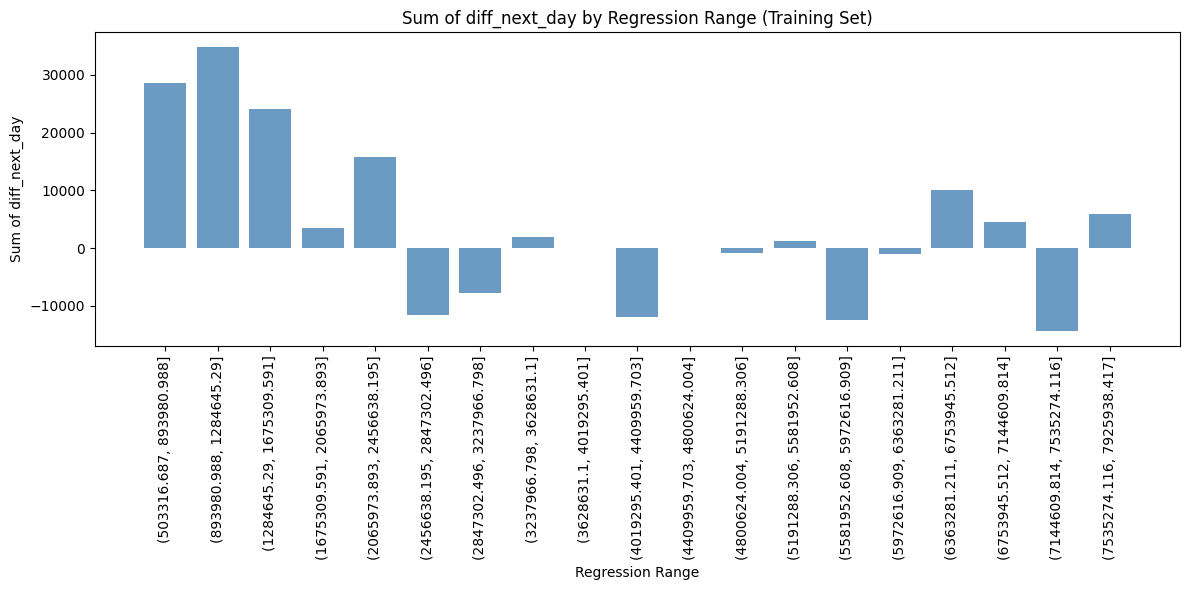

In [112]:
# Bar chart of bins
plt.figure(figsize=(12, 6))
plt.bar(
    table_bins['regression_bin'].astype(str),
    table_bins['sum_diff_next_day'],
    color='steelblue',
    alpha=0.8
)
plt.xticks(rotation=90)
plt.title('Sum of diff_next_day by Regression Range (Training Set)')
plt.xlabel('Regression Range')
plt.ylabel('Sum of diff_next_day')
plt.tight_layout()
plt.show()

In [113]:
# Noticed that the first three bins show mostly positive values,
# so we will take the upper bound of the third bin, and use it as the trading rule threshold
limit_trade = table_bins.loc[2, 'regression_bin'].right
train['trade_signal'] = np.where(train['regression'] <= limit_trade, 1, -1)
train['trade_return'] = train['diff_next_day'] * train['trade_signal']


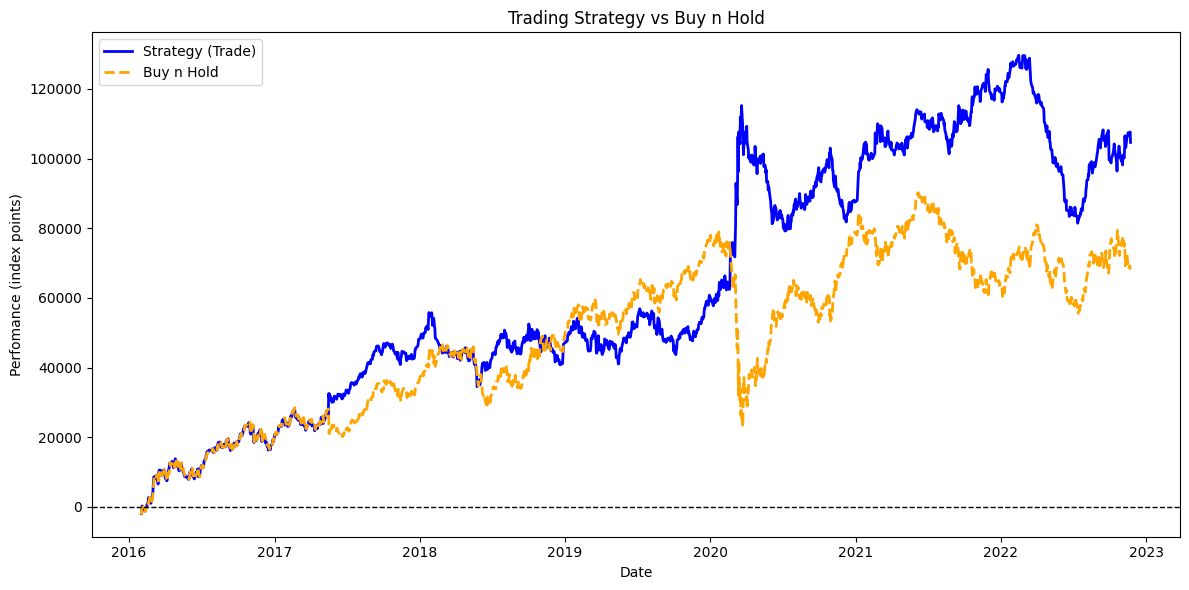

Total return (Trade): 104631.00 points
Total Buy n Hold return: 68113.00 points
Hit rate (Trade): 52.34%
Average daily return: 61.95 points
Std deviation (volatility): 1425.66 points
Sharpe ratio: 0.04
Maximum drawdown: -48207.00 points


In [114]:
# Training Dataset
# Cumulative return of the strategy
train['ret_cum'] = train['trade_return'].cumsum()

# Buy n Hold
train['buy_hold'] = train['Close'] - train['Close'].iloc[0]

# Plot
plt.figure(figsize = (12,6))
plt.plot(train.index, train['ret_cum'], label='Strategy (Trade)', linewidth = 2, color = 'blue')
plt.plot(train.index, train['buy_hold'], label = 'Buy n Hold', linewidth = 2, linestyle = '--', color = 'orange')
plt.axhline(0, color = 'black', linestyle = '--', linewidth = 1)
plt.title('Trading Strategy vs Buy n Hold')
plt.xlabel('Date')
plt.ylabel('Perfomance (index points)')
plt.legend()
plt.tight_layout()
plt.show()

# Statistics
print(f"Total return (Trade): {train['trade_return'].sum():.2f} points")
print(f"Total Buy n Hold return: {train['buy_hold'].iloc[-1]:.2f} points")
print(f"Hit rate (Trade): {(train['trade_return'] > 0).mean() * 100:.2f}%")
mean_return = train['trade_return'].mean()
std_return = train['trade_return'].std()
print(f"Average daily return: {mean_return:.2f} points")
print(f"Std deviation (volatility): {std_return:.2f} points")
print(f"Sharpe ratio: {mean_return / std_return:.2f}")
cumulative = train['ret_cum']
rolling_max = cumulative.cummax()
drawdown = cumulative - rolling_max
max_drawdown = drawdown.min()
print(f"Maximum drawdown: {max_drawdown:.2f} points")

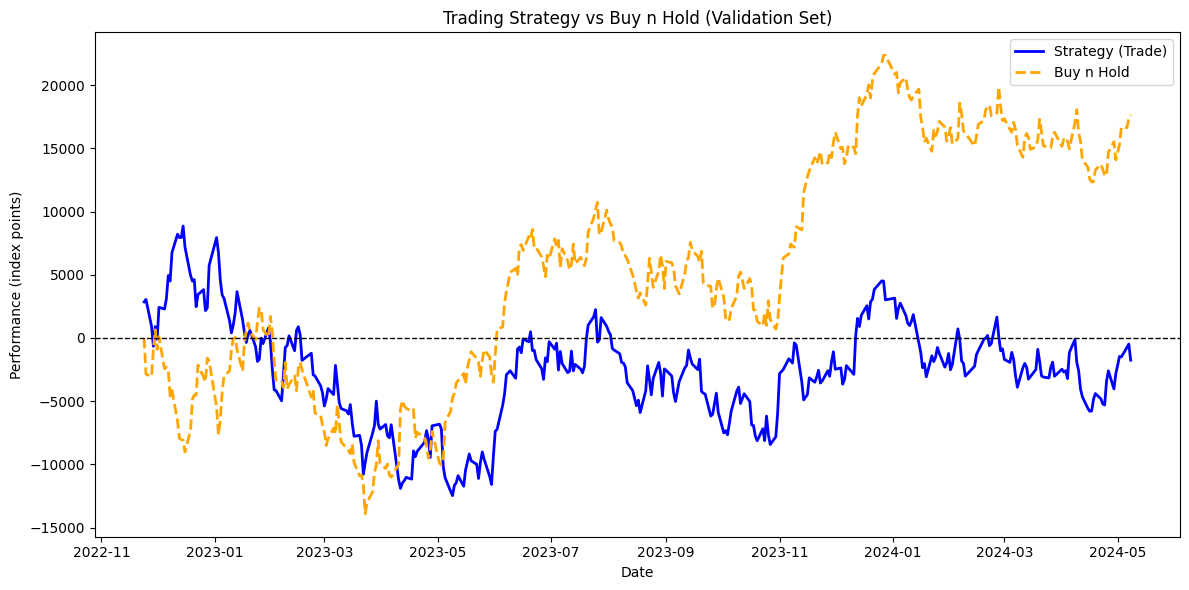

Total return (Trade - Validation): -1757.00 points
Total Buy n Hold return (Validation): 17650.00 points
Hit rate (Trade - Validation): 48.62%
Average daily return: -4.85 points
Std deviation (volatility): 1182.56 points
Sharpe ratio: -0.00
Maximum drawdown: -21323.00 points


In [115]:
# Validation Dataset
# Apply regression value
val['regression'] = beta * val['volatility']

#Generate trade signals
val['trade_signal'] = np.where(val['regression'] <= limit_trade, 1, -1)

# Compute trade returns
val['trade_return'] = val['diff_next_day'] * val['trade_signal']

# Cumulative return
val['ret_cum'] = val['trade_return'].cumsum()

# Buy n Hold
val['buy_hold'] = val['Close'] - val['Close'].iloc[0]

# Plot
plt.figure(figsize = (12,6))
plt.plot(val.index, val['ret_cum'], label='Strategy (Trade)', linewidth = 2, color = 'blue')
plt.plot(val.index, val['buy_hold'], label='Buy n Hold', linewidth = 2, linestyle = '--', color = 'orange')
plt.axhline(0, color = 'black', linestyle = '--', linewidth = 1)
plt.title('Trading Strategy vs Buy n Hold (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Performance (index points)')
plt.legend()
plt.tight_layout()
plt.show()

# Statistics
print(f"Total return (Trade - Validation): {val['trade_return'].sum():.2f} points")
print(f"Total Buy n Hold return (Validation): {val['buy_hold'].iloc[-1]:.2f} points")
print(f"Hit rate (Trade - Validation): {(val['trade_return'] > 0).mean() * 100:.2f}%")
mean_return = val['trade_return'].mean()
std_return = val['trade_return'].std()
sharpe_ratio = mean_return / std_return if std_return != 0 else np.nan
cumulative = val['ret_cum']
rolling_max = cumulative.cummax()
drawdown = cumulative - rolling_max
max_drawdown = drawdown.min()
print(f"Average daily return: {mean_return:.2f} points")
print(f"Std deviation (volatility): {std_return:.2f} points")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")
print(f"Maximum drawdown: {max_drawdown:.2f} points")


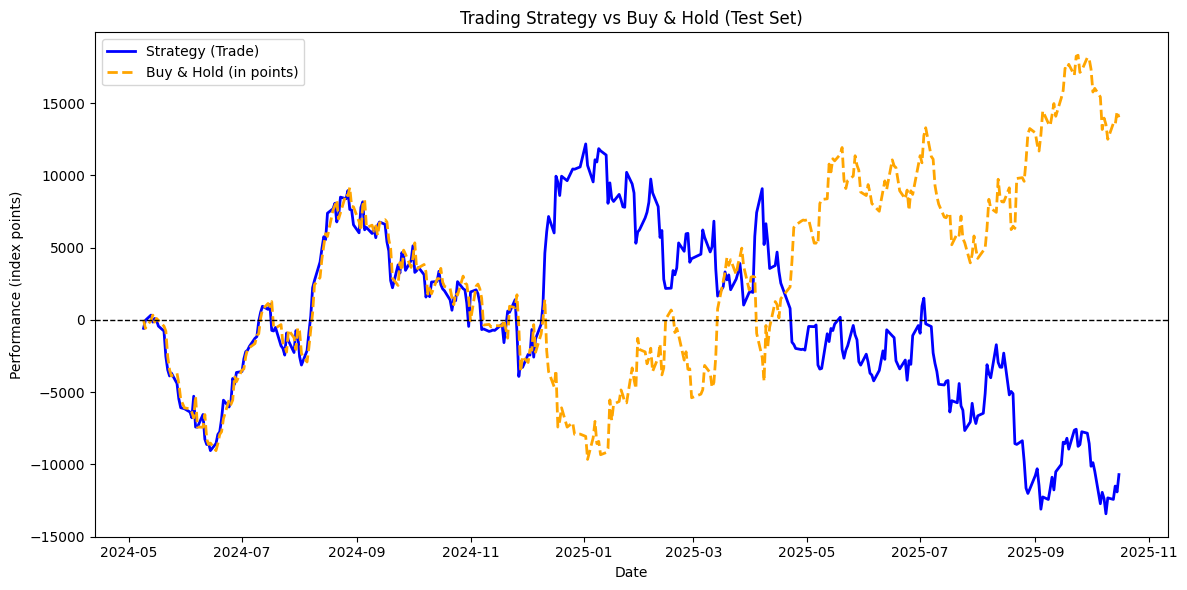

Total return (Trade - Test): -10706.00 points
Total Buy & Hold return (Test): 14012.00 points
Hit rate (Trade - Test): 48.21%
Average daily return: -29.49 points
Std deviation (volatility): 1164.83 points
Sharpe ratio: -0.03
Maximum drawdown: -25588.00 points


In [116]:
# Validation Dataset
# Apply regression value
test['regression'] = beta * test['volatility']

# Generate trade signals
test['trade_signal'] = np.where(test['regression'] <= limit_trade, 1, -1)

# Compute trade returns
test['trade_return'] = test['diff_next_day'] * test['trade_signal']

# Cumulative return
test['ret_cum'] = test['trade_return'].cumsum()

# Buy n Hold
test['buy_hold'] = test['Close'] - test['Close'].iloc[0]

# Plot
plt.figure(figsize = (12,6))
plt.plot(test.index, test['ret_cum'], label = 'Strategy (Trade)', linewidth = 2, color = 'blue')
plt.plot(test.index, test['buy_hold'], label = 'Buy n Hold (in points)', linewidth = 2, linestyle = '--', color = 'orange')
plt.axhline(0, color = 'black', linestyle = '--', linewidth = 1)
plt.title('Trading Strategy vs Buy n Hold (Test Set)')
plt.xlabel('Date')
plt.ylabel('Performance (index points)')
plt.legend()
plt.tight_layout()
plt.show()

# Statistics
print(f"Total return (Trade - Test): {test['trade_return'].sum():.2f} points")
print(f"Total Buy & Hold return (Test): {test['buy_hold'].iloc[-1]:.2f} points")
print(f"Hit rate (Trade - Test): {(test['trade_return'] > 0).mean() * 100:.2f}%")
mean_return = test['trade_return'].mean()
std_return = test['trade_return'].std()
sharpe_ratio = mean_return / std_return if std_return != 0 else np.nan
cumulative = test['ret_cum']
rolling_max = cumulative.cummax()
drawdown = cumulative - rolling_max
max_drawdown = drawdown.min()
print(f"Average daily return: {mean_return:.2f} points")
print(f"Std deviation (volatility): {std_return:.2f} points")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")
print(f"Maximum drawdown: {max_drawdown:.2f} points")

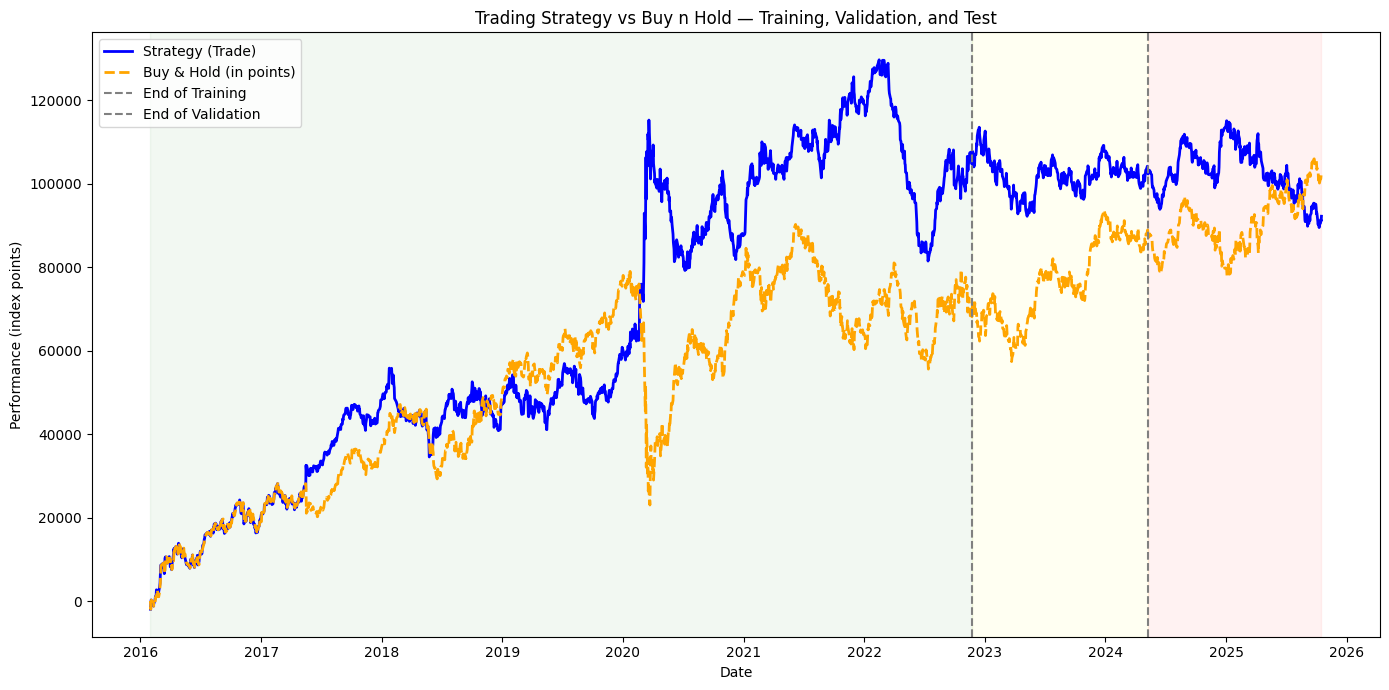

In [120]:
# Combined all datasets
df_combined = pd.concat([
    train.assign(period = 'Training'),
    val.assign(period = 'Validation'),
    test.assign(period = 'Test')
])

# Buy n hold and cumulative return
df_combined['buy_hold_total'] = df_combined['Close'] - df_combined['Close'].iloc[0]
df_combined['ret_cum_total'] = df_combined['trade_return'].cumsum()

# Define the boundaries between periods
end_train_date = train.index.max()
end_val_date = val.index.max()

# Plot
plt.figure(figsize = (14,7))
plt.plot(df_combined.index, df_combined['ret_cum_total'], label='Strategy (Trade)', linewidth = 2, color = 'blue')
plt.plot(df_combined.index, df_combined['buy_hold_total'], label = 'Buy & Hold (in points)', linewidth = 2, linestyle = '--', color = 'orange')

#Separate Lines
plt.axvline(end_train_date, color = 'gray', linestyle = '--', linewidth = 1.5, label = 'End of Training')
plt.axvline(end_val_date, color = 'gray', linestyle = '--', linewidth = 1.5, label = 'End of Validation')

# Background
plt.axvspan(train.index.min(), train.index.max(), color = 'green', alpha = 0.05)
plt.axvspan(val.index.min(), val.index.max(), color = 'yellow', alpha = 0.05)
plt.axvspan(test.index.min(), test.index.max(), color = 'red', alpha = 0.05)

plt.title('Trading Strategy vs Buy n Hold — Training, Validation, and Test')
plt.xlabel('Date')
plt.ylabel('Performance (index points)')
plt.legend()
plt.tight_layout()
plt.show()
